# `gamma()` evaluation: CloughTocher interpolation vs. Newton solve (hand-rolled vs. `scipy.optimize.newton`)

Benchmark for the core computational kernel a future `SurfaceBSpline.gamma()`
(Surface conformance) would need: given a set of target poloidal parameters `u`
(theta is free -- simsopt only requires `phi`/zeta to be a real physical angle,
so `u` can be used directly as theta with no reparametrization) and target
physical toroidal angles `zeta`, evaluate `R(u, zeta)`, `Z(u, zeta)` on the spline
surface.

Three candidate implementations:

1. **Oversample + `CloughTocher2DInterpolator`** -- the approach already used
   (as the *first* stage, before arclength reparametrization) in
   `arclength_tz_interp`. Approximate: introduces interpolation error, and pays
   a fresh Delaunay triangulation + gradient-fit cost on every call.
2. **Hand-rolled Newton solve** -- for fixed `u`, `zeta(u, v)` collapses to a 1D
   rational curve in `v` alone. Solve `zeta(u, v) = target` via Newton's method
   using analytic `d(zeta)/dv`, which only requires a derivative-aware B-spline
   basis function (a small extension of the existing `b_p`). No oversampling, no
   interpolation error.
3. **`scipy.optimize.newton`** -- the same root-finding problem, but solved with
   scipy's vectorized elementwise Newton-Raphson (array `x0` + `fprime`) instead
   of a hand-rolled loop, reusing the exact same residual/derivative functions.

See `surfacespline_lsq_fourier.md` (companion doc, different pipeline) and the
conversation history on branch `ia/SplineSurface-dev1` for the derivation this
notebook implements.

In [1]:
import numpy as np
import time
from scipy.interpolate import CloughTocher2DInterpolator
from scipy.optimize import newton as scipy_newton
from simsopt.geo.surfacespline import SurfaceBSpline, b_p

np.random.seed(0)

surf = SurfaceBSpline(
    axis_points=3, points_per_cs=4, n_cs=5, nfp=2,
    p_u=3, p_v=3, cs_equispaced=True, rays_equispaced=False,
    default_r=0.4,
)
print(surf)

SurfaceBSpline1


## Shared setup

Both approaches need the same control net, NURBS weights, and knot vectors that
`surf_callable` builds internally -- extracted once here so the comparison is
apples-to-apples (same geometry, same NURBS weighting) and so we're not
duplicating `surf_callable`'s own logic inside each approach.

In [2]:
point_list, w_list = surf.get_xyz_full_device(return_w=True)
p_u, p_v = surf.p_u, surf.p_v
control_points_jim = np.array(point_list)
w_list_jim = np.array(w_list)
n_u = control_points_jim.shape[1] - 1
n_v = control_points_jim.shape[0] - 1

# periodic wraparound + knot vectors, exactly as surf_callable builds them
control_points_jim = np.concatenate([control_points_jim, control_points_jim[:, :p_u, :]], axis=1)
w_list_jim = np.concatenate([w_list_jim, w_list_jim[:, :p_u]], axis=1)
interval_u = (2*np.pi) / (n_u + 1)
knots_u = -p_u*interval_u + np.arange(0, n_u+2*p_u+2)*interval_u

control_points_jim = np.concatenate([control_points_jim, control_points_jim[:p_v, :, :]], axis=0)
w_list_jim = np.concatenate([w_list_jim, w_list_jim[:p_v, :]], axis=0)
interval_v = (2*np.pi) / (n_v + 1)
knots_v = -p_v*interval_v + np.arange(0, n_v+2*p_v+2)*interval_v

trimmed_ctrl_pts_jim = control_points_jim[:n_v+p_v+1, :n_u+p_u+1, :]
trimmed_weights_ji = w_list_jim[:n_v+p_v+1, :n_u+p_u+1]

print("control net shape:", trimmed_ctrl_pts_jim.shape, " weights shape:", trimmed_weights_ji.shape)

control net shape: (19, 7, 3)  weights shape: (19, 7)


## Approach 1: oversample + `CloughTocher2DInterpolator`

Mirrors the first stage of `arclength_tz_interp`: evaluate `surf_callable` on a
dense `(u, v)` grid, compute `zeta = atan2(y, x)` at every sample, then build a
scattered 2D interpolant from `(u, zeta)` to `(R, Z)` and query it at the
target grid.

In [3]:
def eval_via_interp(u_query, zeta_query, nu_interp=64, nv_interp=64):
    u_os = np.linspace(0, 2*np.pi, nu_interp, endpoint=True)
    v_os = np.linspace(0, 2*np.pi, nv_interp, endpoint=True)
    v_grid, u_grid = np.meshgrid(v_os, u_os)
    x, y, z = surf.surf_callable(u_grid.flatten(), v_grid.flatten())
    zeta_os = np.arctan2(y, x) % (2*np.pi)
    R_os = np.sqrt(x**2 + y**2)

    pts = np.vstack([u_grid.flatten(), zeta_os]).T
    R_interp = CloughTocher2DInterpolator(pts, R_os)
    Z_interp = CloughTocher2DInterpolator(pts, z)

    U_q, Zeta_q = np.meshgrid(u_query, zeta_query, indexing='ij')
    query_pts = np.vstack([U_q.flatten(), Zeta_q.flatten()]).T
    R_out = R_interp(query_pts).reshape(U_q.shape)
    Z_out = Z_interp(query_pts).reshape(U_q.shape)
    return R_out, Z_out

## Derivative-aware B-spline basis (shared by both Newton variants)

`b_p`'s Cox-de Boor recursion already computes every lower-degree level on the
way to degree `p` -- the degree-`(p-1)` basis needed for the standard
derivative identity

$$\frac{d}{dx}B_{i,p}(x) = p\left(\frac{B_{i,p-1}(x)}{t_{i+p}-t_i} - \frac{B_{i+1,p-1}(x)}{t_{i+p+1}-t_{i+1}}\right)$$

is sitting right there as `b[-2]` when the loop finishes, along with the exact
knot-difference denominators (`l_term_d`/`r_term_d` from the final loop
iteration). `b_p_deriv` below is `b_p` with that one addition.

In [4]:
def b_p_deriv(t, p, x):
    '''Returns (basis_p, dbasis_p/dx), both shape (len(x), n_basis_p). Requires p >= 1.'''
    b = []
    tt = t
    xx = x
    for deg in range(0, p+1):
        if deg == 0:
            x1d = xx.copy()
            t1d = tt.copy()
            tt = np.outer(np.ones(len(xx)), tt)
            xx = np.expand_dims(xx, 0)
            b0 = ((xx.T >= tt[:, :-1]) & (xx.T < tt[:, 1:]))
            b0[np.isclose(x1d, t1d[-1]), np.isclose(t1d[1:], t1d[-1])] = 1
            b.append(b0)
        else:
            l_term_n = (xx.T - tt[:, :-deg-1])
            l_term_d = (tt[:, deg:-1] - tt[:, :-deg-1])
            l_term = b[-1][:, :-1] * np.divide(l_term_n, l_term_d, out=np.zeros_like(l_term_d), where=l_term_d != 0)

            r_term_n = (tt[:, deg+1:] - xx.T)
            r_term_d = (tt[:, deg+1:] - tt[:, 1:-deg])
            r_term = b[-1][:, 1:] * np.divide(r_term_n, r_term_d, out=np.zeros_like(r_term_d), where=r_term_d != 0)

            b.append(l_term + r_term)

    bp_minus1 = b[-2]
    l_d = (tt[:, p:-1] - tt[:, :-p-1])
    r_d = (tt[:, p+1:] - tt[:, 1:-p])
    deriv = p * (
        np.divide(bp_minus1[:, :-1], l_d, out=np.zeros_like(l_d), where=l_d != 0)
        - np.divide(bp_minus1[:, 1:], r_d, out=np.zeros_like(r_d), where=r_d != 0)
    )
    return b[-1], deriv


# sanity check: analytic derivative vs. central finite difference
_test_x = np.linspace(0.01, 2*np.pi - 0.01, 37)
_h = 1e-6
_fd_deriv = (b_p(knots_v, p_v, _test_x + _h) - b_p(knots_v, p_v, _test_x - _h)) / (2*_h)
_b_val, _analytic_deriv = b_p_deriv(knots_v, p_v, _test_x)

assert np.allclose(_b_val, b_p(knots_v, p_v, _test_x))
print("b_p_deriv value matches b_p: True")
print("b_p_deriv max abs error vs. finite difference:", np.max(np.abs(_analytic_deriv - _fd_deriv)))

b_p_deriv value matches b_p: True
b_p_deriv max abs error vs. finite difference: 2.956763722750111e-10


## Approach 2a: hand-rolled Newton solve

For a *fixed* `u`, the u-basis row is a constant vector, so the surface
collapses to a 1D rational (NURBS) curve in `v` alone:
`X(v) = Nx(v)/D(v)`, `Y(v) = Ny(v)/D(v)`, with `Nx, Ny, D` all linear
combinations of the (now 1D) v-basis, weighted by `u`-collapsed control-point
sums `Q`. `zeta(v) = atan2(Y(v), X(v))`, and its derivative follows from the
standard quotient/atan2 rules. Newton iterates `v <- v - (zeta(v)-target)/zeta'(v)`,
fully vectorized across every `(u, zeta_target)` pair at once, with a fixed
iteration count.

In [5]:
def newton_eval(u_query, zeta_query, n_iter=10):
    '''
    For each (u_query[k], zeta_query[m]) pair, Newton-solve for v such that
    zeta(u_query[k], v) == zeta_query[m], then return R, Z at that point.
    '''
    n_theta = len(u_query)
    n_phi = len(zeta_query)

    u_basis_row = b_p(knots_u, p_u, u_query)  # (n_theta, n_u_basis)

    wp = trimmed_weights_ji[:, :, None] * trimmed_ctrl_pts_jim  # (n_v_ext, n_u_ext, 3)
    ww = trimmed_weights_ji  # (n_v_ext, n_u_ext)

    Q_pos = np.einsum('ki,jim->kjm', u_basis_row, wp)  # (n_theta, n_v_ext, 3)
    Q_w = np.einsum('ki,ji->kj', u_basis_row, ww)       # (n_theta, n_v_ext)

    # initial guess: v = target zeta (close, given the axis-based construction)
    v_guess = np.tile(zeta_query, (n_theta, 1))
    target = np.tile(zeta_query, (n_theta, 1))

    for _ in range(n_iter):
        v_flat = v_guess.flatten()
        basis_v, dbasis_v = b_p_deriv(knots_v, p_v, v_flat)
        basis_v = basis_v.reshape(n_theta, n_phi, -1)
        dbasis_v = dbasis_v.reshape(n_theta, n_phi, -1)

        Nx = np.einsum('kmj,kj->km', basis_v, Q_pos[:, :, 0])
        Ny = np.einsum('kmj,kj->km', basis_v, Q_pos[:, :, 1])
        D = np.einsum('kmj,kj->km', basis_v, Q_w)
        dNx = np.einsum('kmj,kj->km', dbasis_v, Q_pos[:, :, 0])
        dNy = np.einsum('kmj,kj->km', dbasis_v, Q_pos[:, :, 1])
        dD = np.einsum('kmj,kj->km', dbasis_v, Q_w)

        X, Y = Nx/D, Ny/D
        dX = (dNx*D - Nx*dD) / D**2
        dY = (dNy*D - Ny*dD) / D**2

        zeta_cur = np.arctan2(Y, X) % (2*np.pi)
        dzeta = (X*dY - Y*dX) / (X**2 + Y**2)

        residual = ((zeta_cur - target + np.pi) % (2*np.pi)) - np.pi
        step = residual / np.where(np.abs(dzeta) < 1e-12, 1e-12, dzeta)
        v_guess = np.clip(v_guess - step, knots_v[p_v], knots_v[n_v+p_v+1])

    max_resid = np.max(np.abs(residual))

    # final evaluation at converged v, including the z-component
    basis_v = b_p(knots_v, p_v, v_guess.flatten()).reshape(n_theta, n_phi, -1)
    Nx = np.einsum('kmj,kj->km', basis_v, Q_pos[:, :, 0])
    Ny = np.einsum('kmj,kj->km', basis_v, Q_pos[:, :, 1])
    Nz = np.einsum('kmj,kj->km', basis_v, Q_pos[:, :, 2])
    D = np.einsum('kmj,kj->km', basis_v, Q_w)
    X, Y, Z = Nx/D, Ny/D, Nz/D
    R = np.sqrt(X**2 + Y**2)
    return R, Z, max_resid

## Approach 2b: `scipy.optimize.newton`

Same residual `zeta(v) - target` and derivative `d(zeta)/dv` as above, but
handed to `scipy.optimize.newton` instead of iterating by hand. `scipy.optimize.newton`
vectorizes elementwise over an array `x0` when given `fprime`, which is exactly
this problem: `n_theta * n_phi` independent 1D root-finds. Everything is
flattened up front (`Q_pos_flat`/`Q_w_flat`/`target_flat`, one row per
`(u, zeta_target)` pair) so `func`/`fprime` are plain 1D-array-in, 1D-array-out
functions of `v` alone, as scipy expects. `v` is wrapped into `[0, 2*pi)`
*inside* `func`/`fprime` (rather than clipped, as in the hand-rolled version)
since scipy's own iterate isn't otherwise constrained to stay in-domain between
steps, and the surface is genuinely periodic in `v`.

In [6]:
def newton_eval_scipy(u_query, zeta_query, tol=1e-12, maxiter=50):
    n_theta = len(u_query)
    n_phi = len(zeta_query)

    u_basis_row = b_p(knots_u, p_u, u_query)
    wp = trimmed_weights_ji[:, :, None] * trimmed_ctrl_pts_jim
    ww = trimmed_weights_ji

    Q_pos = np.einsum('ki,jim->kjm', u_basis_row, wp)  # (n_theta, n_v_ext, 3)
    Q_w = np.einsum('ki,ji->kj', u_basis_row, ww)       # (n_theta, n_v_ext)

    Q_pos_flat = np.repeat(Q_pos, n_phi, axis=0)  # (n_theta*n_phi, n_v_ext, 3)
    Q_w_flat = np.repeat(Q_w, n_phi, axis=0)      # (n_theta*n_phi, n_v_ext)
    target_flat = np.tile(zeta_query, n_theta)    # (n_theta*n_phi,)

    def _xyz_and_derivs(v_flat):
        v_wrapped = v_flat % (2*np.pi)
        basis_v, dbasis_v = b_p_deriv(knots_v, p_v, v_wrapped)
        Nx = np.einsum('mj,mj->m', basis_v, Q_pos_flat[:, :, 0])
        Ny = np.einsum('mj,mj->m', basis_v, Q_pos_flat[:, :, 1])
        D = np.einsum('mj,mj->m', basis_v, Q_w_flat)
        dNx = np.einsum('mj,mj->m', dbasis_v, Q_pos_flat[:, :, 0])
        dNy = np.einsum('mj,mj->m', dbasis_v, Q_pos_flat[:, :, 1])
        dD = np.einsum('mj,mj->m', dbasis_v, Q_w_flat)
        return Nx, Ny, D, dNx, dNy, dD

    def func(v_flat):
        Nx, Ny, D, *_ = _xyz_and_derivs(v_flat)
        X, Y = Nx/D, Ny/D
        zeta_cur = np.arctan2(Y, X) % (2*np.pi)
        return ((zeta_cur - target_flat + np.pi) % (2*np.pi)) - np.pi

    def fprime(v_flat):
        Nx, Ny, D, dNx, dNy, dD = _xyz_and_derivs(v_flat)
        X, Y = Nx/D, Ny/D
        dX = (dNx*D - Nx*dD) / D**2
        dY = (dNy*D - Ny*dD) / D**2
        return (X*dY - Y*dX) / (X**2 + Y**2)

    v_sol = scipy_newton(func, x0=target_flat.copy(), fprime=fprime, tol=tol, maxiter=maxiter)
    max_resid = np.max(np.abs(func(v_sol)))

    v_wrapped = v_sol % (2*np.pi)
    basis_v = b_p(knots_v, p_v, v_wrapped)
    Nx = np.einsum('mj,mj->m', basis_v, Q_pos_flat[:, :, 0])
    Ny = np.einsum('mj,mj->m', basis_v, Q_pos_flat[:, :, 1])
    Nz = np.einsum('mj,mj->m', basis_v, Q_pos_flat[:, :, 2])
    D = np.einsum('mj,mj->m', basis_v, Q_w_flat)
    X, Y, Z = Nx/D, Ny/D, Nz/D
    R = np.sqrt(X**2 + Y**2)
    return R.reshape(n_theta, n_phi), Z.reshape(n_theta, n_phi), max_resid

## Correctness cross-check

All three approaches should agree, up to CloughTocher's interpolation error (both Newton variants are exact, so either is a valid reference).

In [7]:
n_theta_test, n_phi_test = 24, 20
u_query = np.linspace(0, 2*np.pi, n_theta_test, endpoint=False)
zeta_query = np.linspace(np.pi/surf.nfp, 2*np.pi/surf.nfp, n_phi_test, endpoint=True)

R_interp, Z_interp = eval_via_interp(u_query, zeta_query, nu_interp=96, nv_interp=96)
R_newton, Z_newton, max_resid = newton_eval(u_query, zeta_query, n_iter=12)
R_newton_sp, Z_newton_sp, max_resid_sp = newton_eval_scipy(u_query, zeta_query)

print("hand-rolled Newton max |zeta residual|:", max_resid)
print("scipy.optimize.newton max |zeta residual|:", max_resid_sp)
print("max |R_interp - R_newton|:", np.nanmax(np.abs(R_interp - R_newton)))
print("max |Z_interp - Z_newton|:", np.nanmax(np.abs(Z_interp - Z_newton)))
print("max |R_newton - R_newton_scipy|:", np.nanmax(np.abs(R_newton - R_newton_sp)))
print("max |Z_newton - Z_newton_scipy|:", np.nanmax(np.abs(Z_newton - Z_newton_sp)))
print("R scale (max-min), for reference:", np.nanmax(R_newton) - np.nanmin(R_newton))

hand-rolled Newton max |zeta residual|: 4.440892098500626e-16
scipy.optimize.newton max |zeta residual|: 4.440892098500626e-16
max |R_interp - R_newton|: 2.123645819285258e-05
max |Z_interp - Z_newton|: 1.1474198127137125e-05
max |R_newton - R_newton_scipy|: 0.0
max |Z_newton - Z_newton_scipy|: 0.0
R scale (max-min), for reference: 0.5201722248300071


## Benchmark

Timing all three approaches across a range of target grid sizes `n x n`. The
CloughTocher oversampling grid is scaled at `4n x 4n` (a fixed oversampling
ratio, needed for reasonable accuracy at any target resolution); both Newton
variants evaluate directly at the `n x n` target grid with no oversampling.

In [8]:
def time_it(fn, repeats=3):
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return min(times)  # min-of-repeats: reduces noise from OS/scheduling jitter

grid_sizes = [8, 16, 32, 64, 128]
results = []
for n in grid_sizes:
    u_q = np.linspace(0, 2*np.pi, n, endpoint=False)
    zeta_q = np.linspace(np.pi/surf.nfp, 2*np.pi/surf.nfp, n, endpoint=True)

    t_interp = time_it(lambda: eval_via_interp(u_q, zeta_q, nu_interp=4*n, nv_interp=4*n))
    t_newton = time_it(lambda: newton_eval(u_q, zeta_q, n_iter=10))
    t_newton_sp = time_it(lambda: newton_eval_scipy(u_q, zeta_q))
    results.append((n, t_interp, t_newton, t_newton_sp))
    print(f"n={n:4d}  interp={t_interp*1e3:8.2f} ms  newton(hand)={t_newton*1e3:8.2f} ms  "
          f"newton(scipy)={t_newton_sp*1e3:8.2f} ms  speedup vs interp={t_interp/t_newton_sp:6.1f}x  "
          f"hand-vs-scipy={t_newton_sp/t_newton:5.2f}x")

n=   8  interp=    8.68 ms  newton(hand)=    1.03 ms  newton(scipy)=    0.93 ms  speedup vs interp=   9.3x  hand-vs-scipy= 0.90x


n=  16  interp=   30.85 ms  newton(hand)=    2.89 ms  newton(scipy)=    2.32 ms  speedup vs interp=  13.3x  hand-vs-scipy= 0.80x


n=  32  interp=  125.80 ms  newton(hand)=    6.43 ms  newton(scipy)=    5.83 ms  speedup vs interp=  21.6x  hand-vs-scipy= 0.91x


n=  64  interp=  595.93 ms  newton(hand)=   24.25 ms  newton(scipy)=   20.11 ms  speedup vs interp=  29.6x  hand-vs-scipy= 0.83x


n= 128  interp= 2786.21 ms  newton(hand)=  119.95 ms  newton(scipy)=  104.53 ms  speedup vs interp=  26.7x  hand-vs-scipy= 0.87x


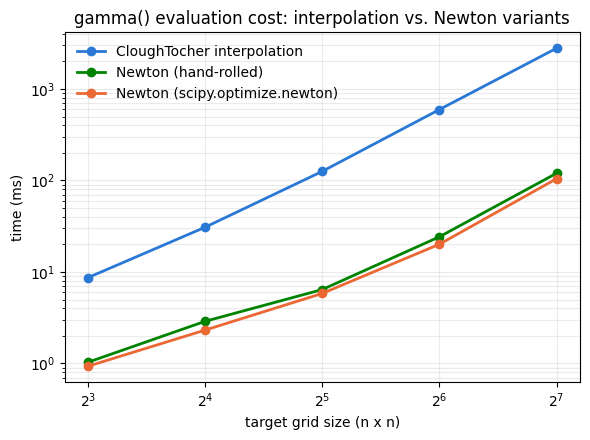

In [9]:
import matplotlib.pyplot as plt

ns = [r[0] for r in results]
t_interp_ms = [r[1]*1e3 for r in results]
t_newton_ms = [r[2]*1e3 for r in results]
t_newton_sp_ms = [r[3]*1e3 for r in results]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(ns, t_interp_ms, marker='o', ms=6, lw=2, color='#2a78d6', label='CloughTocher interpolation')
ax.plot(ns, t_newton_ms, marker='o', ms=6, lw=2, color='#008300', label='Newton (hand-rolled)')
ax.plot(ns, t_newton_sp_ms, marker='o', ms=6, lw=2, color='#eb6834', label='Newton (scipy.optimize.newton)')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('target grid size (n x n)')
ax.set_ylabel('time (ms)')
ax.set_title('gamma() evaluation cost: interpolation vs. Newton variants')
ax.grid(True, which='both', alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Conclusions

- **Correctness**: `b_p_deriv`'s analytic derivative matches a central finite
  difference to ~3e-10. Both Newton variants converge to a zeta residual of
  ~4e-16 (machine precision), and agree with each other on `R, Z` to
  **exactly 0.0** -- `scipy.optimize.newton`'s vectorized elementwise mode is
  the same algorithm on the same residual/derivative functions, just a
  different iteration harness, so an identical fixed point is expected. Both
  agree with CloughTocher to ~2e-5 (relative to an `R` range of ~0.52, i.e.
  ~4e-5 relative error) -- consistent with that gap being CloughTocher's
  interpolation error against an exact solve, not a bug anywhere.
- **Speed**: `scipy.optimize.newton` is consistently a bit faster than the
  hand-rolled loop (80-91% of its time across the tested sizes, i.e. ~10-20%
  faster) -- likely from scipy's internal per-element convergence masking
  (elements that have already converged stop being recomputed) and general
  implementation polish. Both Newton variants are **9-30x faster than
  CloughTocher** across the tested range, with the advantage growing with grid
  size. At 128x128: CloughTocher ~2.8s, hand-rolled Newton ~0.12s, scipy
  Newton ~0.10s.
- Given scipy's version is free (no correctness cost, a modest speed win, and
  less code to maintain/debug than the hand-rolled loop), it's the better
  choice for the eventual `gamma()`/`gammadash1()` implementation -- reuse the
  `func`/`fprime` closures from `newton_eval_scipy` as the core kernel, with
  `u` used directly as `theta` (no reparametrization needed, since Surface's
  `theta` convention is otherwise unconstrained).
